**intergenic/genic**


Genome proportions:
        species  genic_genome_prop  intergenic_genome_prop
        cjejuni           0.926159                0.073841
   sepidermidis           0.831159                0.168841
     bpertussis           0.853005                0.146995
    spneumoniae           0.831355                0.168645
    paeruginosa           0.888970                0.111030
    hinfluenzae           0.882575                0.117425
   styphimurium           0.873993                0.126007
    kpneumoniae           0.850321                0.149679
        saureus           0.842683                0.157317
  nmeningitidis           0.789698                0.210302
  mtuberculosis           0.883175                0.116825
lmonocytogenesA           0.899424                0.100576
          ecoli           0.861464                0.138536
    sagalactiae           0.876653                0.123347
Saved genic_chisq_results.csv

Descriptive statistics:
             metric     mean   median  

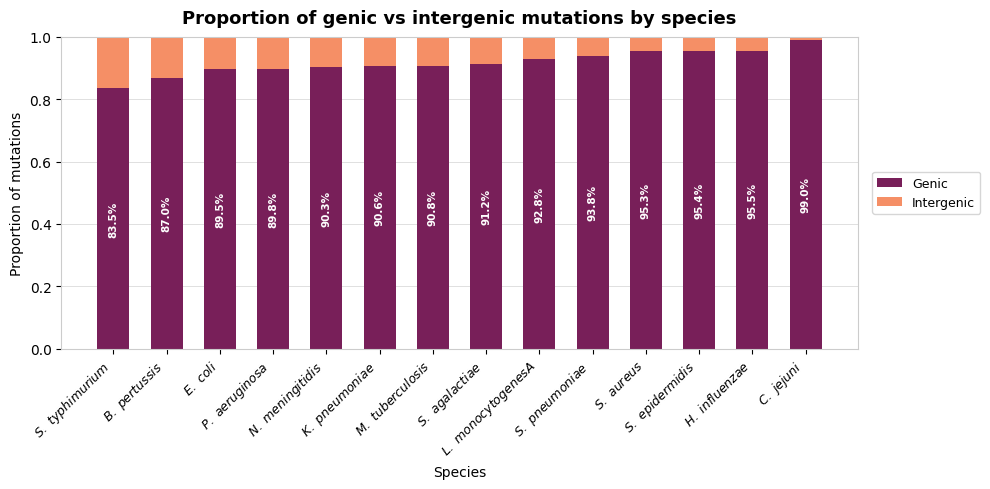

Saved genic_intergenic_proportions.png


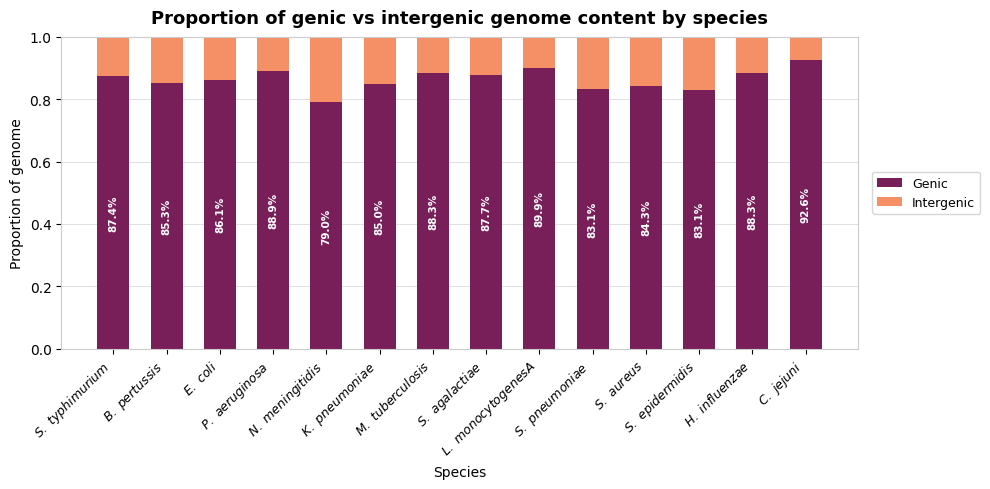

Saved genic_intergenic_content.png


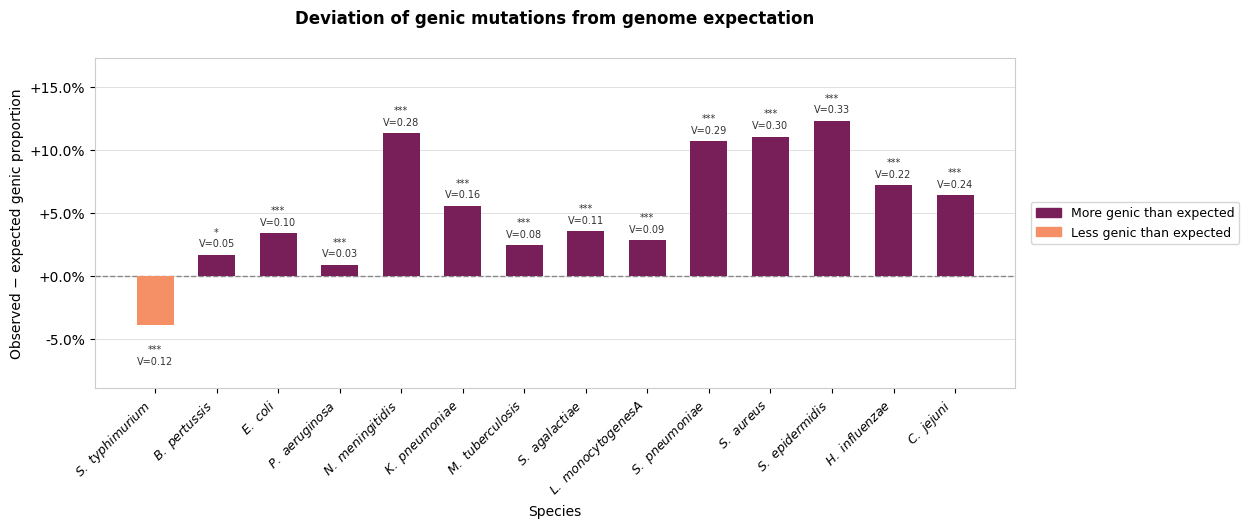

Saved genic_difference_plot.png


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chisquare
from statsmodels.stats.multitest import multipletests

# find paths
base_folder      = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files"
)
processed_folder = os.path.join(base_folder, "processed_c")
output_folder    = os.path.join(processed_folder, "charts", "genic_intergenic")
os.makedirs(output_folder, exist_ok=True)

mutation_csv = os.path.join(processed_folder, "mutation_summary_final_c.csv")

DPI = 300

# define colours as before
PALETTE           = sns.color_palette("rocket", 12)
colour_genic      = PALETTE[3]
colour_intergenic = PALETTE[9]

####################
#functions

def significance_stars(p):
    if p < 0.001:  return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else:          return "ns"

#find gene position from gff
def parse_gff_genes(gff_file):
    genes = []
    with open(gff_file) as f:
        for line in f:
            if line.startswith("#"):
                continue
            cols = line.strip().split("\t")
            if len(cols) < 5:
                continue
            chrom, _, feature, start, end = cols[:5]
            if feature == "gene":
                genes.append((chrom, int(start) - 1, int(end)))
    return genes

# merges gene intervals if they overlap to avoid double counting
def merge_intervals(intervals):
    if not intervals:
        return []
    intervals.sort(key=lambda x: (x[0], x[1]))
    merged = [list(intervals[0])]
    for chrom, start, end in intervals[1:]:
        last_chrom, last_start, last_end = merged[-1]
        if chrom != last_chrom or start > last_end:
            merged.append([chrom, start, end])
        else:
            merged[-1][2] = max(last_end, end)
    return merged

# uses functions above to get the genic portion of genome
def compute_genic_bp(gff_file):
    genes  = parse_gff_genes(gff_file)
    merged = merge_intervals(genes)
    return sum(end - start for _, start, end in merged)

# gets genome size
def genome_size(fasta_file):
    total = 0
    with open(fasta_file) as f:
        for line in f:
            if not line.startswith(">"):
                total += len(line.strip())
    return total


def format_species_name(name):
    return f"$\\it{{{name[0].upper()}.\\ {name[1:]}}}$"

#consistent styling for graphs
def setup_stacked_ax(ax, x, formatted_order):
    ax.set_xticks(x)
    ax.set_xticklabels(formatted_order, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    ax.yaxis.grid(True, color="#E0E0E0", linewidth=0.7)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")
    ax.legend(fontsize=9, frameon=True, edgecolor="#CCCCCC",
              loc="center left", bbox_to_anchor=(1.01, 0.5))

#################
#read file and find intergenic and gff file, compute genic and genome size, calculate intergenic proportion too
mut_df = pd.read_csv(mutation_csv)
mut_df["is_intergenic"] = (
    mut_df["is_intergenic"].astype(str).str.strip().str.lower()
    .map({"true": True, "false": False, "1": True, "0": False})
)

fasta_files = glob.glob(os.path.join(base_folder, "*.fna"))
genome_rows = []

for fasta_file in fasta_files:
    species  = os.path.basename(fasta_file).replace(".fna", "")
    gff_file = os.path.join(base_folder, species + ".gff")

    genome_bp = genome_size(fasta_file)
    genic_bp  = compute_genic_bp(gff_file)
    genome_rows.append({
        "species":                species,
        "genic_genome_prop":      genic_bp / genome_bp,
        "intergenic_genome_prop": 1 - (genic_bp / genome_bp),
    })
#print proportions of each species
genome_df = pd.DataFrame(genome_rows)
print("\nGenome proportions:")
print(genome_df.to_string(index=False))

###################
#count actually observed mutations for each species
species_list = sorted(mut_df["species"].unique())
mut_rows     = []

for species in species_list:
    sp_df     = mut_df[mut_df["species"] == species]
    genic_obs = sp_df[sp_df["is_intergenic"] == False]["no_mutations"].sum()
    inter_obs = sp_df[sp_df["is_intergenic"] == True]["no_mutations"].sum()
    mut_rows.append({
        "species":   species,
        "genic_obs": genic_obs,
        "inter_obs": inter_obs,
        "total_obs": genic_obs + inter_obs,
    })

obs_df = pd.DataFrame(mut_rows)
merged = obs_df.merge(genome_df, on="species", how="inner")

########################
#stats: chi squared and cramers V
results = []

for _, row in merged.iterrows():
    observed = np.array([row["genic_obs"],  row["inter_obs"]])
    expected = np.array([
        row["total_obs"] * row["genic_genome_prop"],
        row["total_obs"] * row["intergenic_genome_prop"],
    ])
    chi2, p   = chisquare(f_obs=observed, f_exp=expected)
    cramers_v = np.sqrt(chi2 / row["total_obs"])
    #find difference between observed and expected
    obs_genic_prop = row["genic_obs"] / row["total_obs"]
    difference     = obs_genic_prop - row["genic_genome_prop"]

    results.append({
        "species":             row["species"],
        "observed_genic_prop": obs_genic_prop,
        "expected_genic_prop": row["genic_genome_prop"],
        "difference":          difference,
        "genic_obs":           int(row["genic_obs"]),
        "inter_obs":           int(row["inter_obs"]),
        "total_obs":           int(row["total_obs"]),
        "chi2":                round(chi2, 4),
        "cramers_v":           round(cramers_v, 4),
        "p_value":             p,
    })

results_df = pd.DataFrame(results)

reject, p_adj, _, _ = multipletests(results_df["p_value"], method="fdr_bh")
results_df["p_adj_BH"]    = p_adj
results_df["significant"] = reject
results_df["stars"]       = results_df["p_adj_BH"].apply(significance_stars)

results_df.to_csv(os.path.join(output_folder, "genic_chisq_results.csv"), index=False)
print("Saved genic_chisq_results.csv")

#descriptive statistics, save
desc_df = (
    results_df[["observed_genic_prop", "expected_genic_prop", "difference"]]
    .agg(["mean", "median", "std"])
    .round(6)
    .T
    .rename(columns={"std": "sd"})
    .reset_index()
    .rename(columns={"index": "metric"})
)

print("\nDescriptive statistics:")
print(desc_df.to_string(index=False))
print("\nPer species:")
print(results_df[["species", "observed_genic_prop", "expected_genic_prop",
                   "difference"]].to_string(index=False))

desc_df.to_csv(os.path.join(output_folder, "genic_descriptive_stats.csv"), index=False)
print("Saved genic_descriptive_stats.csv")


###############
#plots, keep species order the same throughout and same size
species_order   = results_df.sort_values("observed_genic_prop")["species"].tolist()
formatted_order = [format_species_name(sp) for sp in species_order]
x               = np.arange(len(species_order))
bar_w           = 0.6

#plot1: proportion of mutations in intergenic and genic
prop_rows = []
for species in species_order:
    sp_df       = mut_df[mut_df["species"] == species]
    genic_total = sp_df[sp_df["is_intergenic"] == False]["no_mutations"].sum()
    inter_total = sp_df[sp_df["is_intergenic"] == True]["no_mutations"].sum()
    total       = genic_total + inter_total
    prop_rows.append({
        "species":    species,
        "genic_prop": genic_total / total,
        "inter_prop": inter_total / total,
    })

prop_df          = pd.DataFrame(prop_rows)
genic_props      = prop_df["genic_prop"].values
intergenic_props = prop_df["inter_prop"].values

fig, ax = plt.subplots(figsize=(max(10, len(species_order) * 0.7), 5))
ax.bar(x, genic_props,      width=bar_w, color=colour_genic,      label="Genic")
ax.bar(x, intergenic_props, width=bar_w, bottom=genic_props,
       color=colour_intergenic, label="Intergenic")

for i in range(len(species_order)):
    ax.text(x[i], genic_props[i] / 2, f"{genic_props[i]:.1%}",
            ha="center", va="center", fontsize=7.5,
            color="white", fontweight="bold", rotation=90)

ax.set_ylabel("Proportion of mutations", fontsize=10)
ax.set_xlabel("Species", fontsize=10)
ax.set_title("Proportion of genic vs intergenic mutations by species",
             fontsize=13, fontweight="bold", pad=10)
setup_stacked_ax(ax, x, formatted_order)

plt.tight_layout()
fig.savefig(os.path.join(output_folder, "genic_intergenic_proportions.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved genic_intergenic_proportions.png")


# plot 2: proportion of genes in genome - same process as before
genome_df_ord     = genome_df.set_index("species").reindex(species_order).reset_index()
genome_genic      = genome_df_ord["genic_genome_prop"].values
genome_intergenic = genome_df_ord["intergenic_genome_prop"].values

fig, ax = plt.subplots(figsize=(max(10, len(species_order) * 0.7), 5))
ax.bar(x, genome_genic,      width=bar_w, color=colour_genic,      label="Genic")
ax.bar(x, genome_intergenic, width=bar_w, bottom=genome_genic,
       color=colour_intergenic, label="Intergenic")

for i in range(len(species_order)):
    ax.text(x[i], genome_genic[i] / 2, f"{genome_genic[i]:.1%}",
            ha="center", va="center", fontsize=7.5,
            color="white", fontweight="bold", rotation=90)

ax.set_ylabel("Proportion of genome", fontsize=10)
ax.set_xlabel("Species", fontsize=10)
ax.set_title("Proportion of genic vs intergenic genome content by species",
             fontsize=13, fontweight="bold", pad=10)
setup_stacked_ax(ax, x, formatted_order)

plt.tight_layout()
fig.savefig(os.path.join(output_folder, "genic_intergenic_content.png"),
            dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved genic_intergenic_content.png")


#plot 3: difference plot showing statistical results
results_df = results_df.set_index("species").reindex(species_order).reset_index()
colours_diff = [colour_genic if d >= 0 else colour_intergenic
                for d in results_df["difference"]]

fig, ax = plt.subplots(figsize=(max(5, len(species_order) * 0.9), 5))

ax.bar(x, results_df["difference"], width=bar_w, color=colours_diff, zorder=3)

for i, (_, row) in enumerate(results_df.iterrows()):
    y_pos = row["difference"] + (0.005 if row["difference"] >= 0 else -0.016)
    ax.text(x[i], y_pos,
            f"{row['stars']}\nV={row['cramers_v']:.2f}",
            ha="center",
            va="bottom" if row["difference"] >= 0 else "top",
            fontsize=7, color="#333333")

ax.axhline(0, color="#888888", linewidth=1, linestyle="--", zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(formatted_order, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Observed − expected genic proportion", fontsize=10)
ax.set_xlabel("Species", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1%}"))
ax.set_title("Deviation of genic mutations from genome expectation\n",
             fontsize=12, fontweight="bold", pad=10)
ax.set_ylim(results_df["difference"].min() - 0.05,
            results_df["difference"].max() + 0.05)
ax.yaxis.grid(True, color="#E0E0E0", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")
    
#legend
legend_handles = [
    mpatches.Patch(color=colour_genic,      label="More genic than expected"),
    mpatches.Patch(color=colour_intergenic, label="Less genic than expected"),
]
ax.legend(handles=legend_handles, fontsize=9, frameon=True,
          facecolor="white", edgecolor="#CCCCCC",
          loc="center left", bbox_to_anchor=(1.01, 0.5))

plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.savefig(os.path.join(output_folder, "genic_difference_plot.png"),
            dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved genic_difference_plot.png")